# K06_05 – XGBoost für Fraud Detection

Update am 25. Mai 2026

## Lernziele
Nach diesem Notebook koennen Sie:
- erklaeren, warum **Fraud Detection** ein besonders schwieriges ML-Problem ist
- **extremes Klassenungleichgewicht** (0.17% Betrug) erkennen und behandeln
- `scale_pos_weight` gezielt einsetzen
- **Precision, Recall, F1 und ROC-AUC** im Kontext Fraud richtig interpretieren
- den **Schwellwert** anpassen und den Precision-Recall-Trade-off demonstrieren
- **Feature Importance** auf anonymisierten PCA-Features deuten
- den **SHAP-Wert** als Erklaerungswerkzeug einsetzen (Bonus)

---

**Warum Fraud Detection?**

Dieser Datensatz stammt aus realen Kreditkartentransaktionen europaeischer
Karteninhaber (September 2013, 2 Tage). Er hat:

| Eigenschaft | Wert |
|---|---|
| Transaktionen gesamt | 284.807 |
| Betrug-Faelle | 492 (0.17%) |
| Features | V1-V28 (PCA), Time, Amount |
| Klasse 0 | legitim |
| Klasse 1 | Betrug |

> Ein Modell, das **immer 'legitim'** vorhersagt, haette 99.83% Accuracy
> -- aber wuerde jeden Betrugsfall verpassen. Das ist der Kernkonflikt.


## Installation und Datensatz

```python
# Falls nicht installiert:
# !pip install xgboost kagglehub
```

**Datensatz:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Der Download erfolgt automatisch ueber `kagglehub`.
Kaggle-Account erforderlich (einmalige Anmeldung in Colab).

**Alternativ:** CSV-Datei manuell von Kaggle herunterladen und in Colab hochladen.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score, RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_score, recall_score, f1_score
)

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
    print('XGBoost erfolgreich geladen.')
except ImportError:
    XGBOOST_OK = False
    print('XGBoost nicht gefunden -> !pip install xgboost')


XGBoost erfolgreich geladen.


## 1. Datensatz laden

Die Features V1-V28 sind bereits **PCA-transformiert** (anonymisiert).
Nur `Time` und `Amount` sind im Original-Massstab.


In [2]:
import kagglehub, os

path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))

print(f'Datensatz geladen: {df.shape[0]:,} Zeilen, {df.shape[1]} Spalten')
print(f'Features: {list(df.columns)}')
df.head(3)


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Datensatz geladen: 284,807 Zeilen, 31 Spalten
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 2. Exploration: Klassenverteilung und Betrag


Klassenverteilung:
  Klasse 0 (legitim): 284,315 (99.83%)
  Klasse 1 (Betrug):      492 (0.17%)

Ein Modell das immer "legitim" vorhersagt haette:
  Accuracy = 99.8273%  -- aber 0 erkannte Betruegsfaelle!


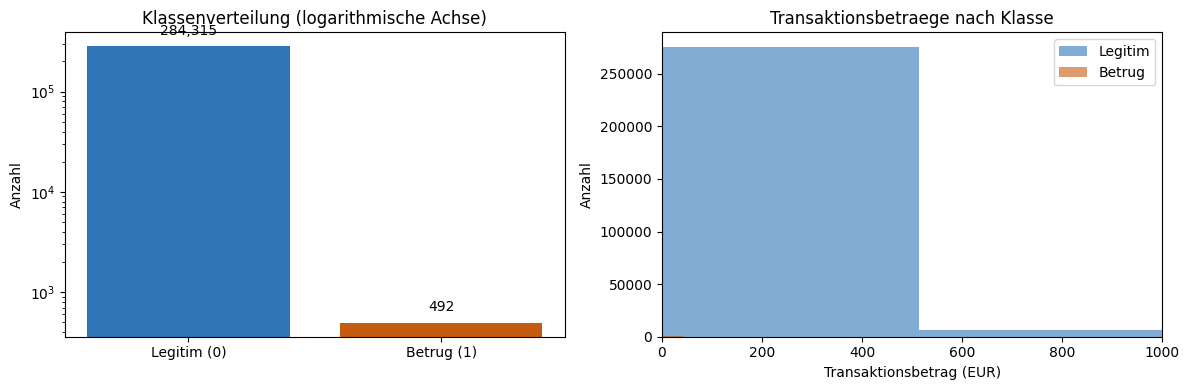

In [3]:
# Klassenverteilung
counts = df['Class'].value_counts()
fraud_rate = counts[1] / len(df)

print('Klassenverteilung:')
print(f'  Klasse 0 (legitim): {counts[0]:>7,} ({1-fraud_rate:.2%})')
print(f'  Klasse 1 (Betrug):  {counts[1]:>7,} ({fraud_rate:.2%})')
print()
print(f'Ein Modell das immer "legitim" vorhersagt haette:')
print(f'  Accuracy = {1-fraud_rate:.4%}  -- aber 0 erkannte Betruegsfaelle!')

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Klassenverteilung
axes[0].bar(['Legitim (0)', 'Betrug (1)'], [counts[0], counts[1]],
            color=['#2E75B6', '#C55A11'])
axes[0].set_title('Klassenverteilung (logarithmische Achse)')
axes[0].set_ylabel('Anzahl')
axes[0].set_yscale('log')   # logarithmisch wegen extremem Ungleichgewicht
for i, (label, val) in enumerate(zip(['Legitim', 'Betrug'], counts.values)):
    axes[0].text(i, val * 1.3, f'{val:,}', ha='center', fontsize=10)

# Betragverteilung
for klasse, farbe, label in zip([0, 1], ['#2E75B6', '#C55A11'],
                                  ['Legitim', 'Betrug']):
    axes[1].hist(df[df['Class']==klasse]['Amount'],
                bins=50, alpha=0.6, color=farbe, label=label)
axes[1].set_xlabel('Transaktionsbetrag (EUR)')
axes[1].set_ylabel('Anzahl')
axes[1].set_title('Transaktionsbetraege nach Klasse')
axes[1].set_xlim(0, 1000)
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Warum Accuracy hier versagt

Bei 99.83% legitimen Transaktionen gilt:

```
Dummes Modell: Sage immer 'legitim'
  -> Accuracy = 99.83%  (klingt gut!)
  -> Recall Betrug = 0%  (jeden Betrug verpasst)
  -> F1 Betrug = 0.0     (voellig nutzlos)
```

**Die richtigen Metriken fuer Fraud Detection:**

| Metrik | Fragestellung | Wichtig weil |
|---|---|---|
| **Recall (Betrug)** | Wie viele Betruegsfaelle erkennen wir? | jeder verpasste Betrug = echter Schaden |
| **Precision (Betrug)** | Wie viele Alarm-Faelle sind wirklich Betrug? | zu viele Fehlalarme nerven Kunden |
| **F1 (Betrug)** | Balance aus Precision und Recall | zusammenfassende Guetezahl |
| **ROC-AUC** | Trennfaehigkeit ueber alle Schwellwerte | Schwellwert-unabhaengige Bewertung |

> **Merksatz:** Im Fraud-Kontext ist **Recall** oft wichtiger als Precision:
> lieber zu viele Fehlalarme als einen echten Betrug verpassen.


## 4. Features, Labels und Train/Test-Split

`stratify=y` ist hier besonders wichtig: ohne stratify koennte ein Fold
gar keine oder sehr wenige Betruegsfaelle enthalten.


In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

print(f'Feature-Matrix X: {X.shape}')
print(f'Zielvariable y:   {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y   # Betrugsrate in Train und Test gleich halten
)

print(f'\nTrainingsdaten:  {len(X_train):,} Transaktionen')
print(f'Testdaten:       {len(X_test):,} Transaktionen')
print(f'Betrug im Test:  {y_test.sum()} Faelle ({y_test.mean():.2%})')


Feature-Matrix X: (284807, 30)
Zielvariable y:   (284807,)

Trainingsdaten:  227,845 Transaktionen
Testdaten:       56,962 Transaktionen
Betrug im Test:  98 Faelle (0.17%)


## 5. Klassenungleichgewicht behandeln: scale_pos_weight

XGBoost's `scale_pos_weight` verstaerkt die Bestrafung fuer verpasste Betruegsfaelle
in der Verlustfunktion:

```
scale_pos_weight = Anzahl negative Faelle / Anzahl positive Faelle
                 ≈ 577 (bei diesem Datensatz)
```

Das bedeutet: Ein verpasster Betrugsfall wird vom Modell ~577x staerker
bestraft als eine falsch klassifizierte legitime Transaktion.


In [5]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale_pw = round(negative / positive, 1)

print(f'Legitime Transaktionen:    {negative:,}')
print(f'Betrugs-Transaktionen:     {positive:,}')
print(f'scale_pos_weight:          {scale_pw}')
print(f'-> Betrugsfall wird {scale_pw}x staerker gewichtet')


Legitime Transaktionen:    227,451
Betrugs-Transaktionen:     394
scale_pos_weight:          577.3
-> Betrugsfall wird 577.3x staerker gewichtet


## 6. XGBoost-Modell definieren

### Parameter-Erklaerung

| Parameter | Wert | Bedeutung |
|---|---|---|
| `n_estimators` | 200 | Anzahl Boosting-Runden |
| `max_depth` | 5 | Maximale Tiefe jedes Baums |
| `learning_rate` | 0.05 | Kleine Schritte -> robuster gegen Overfitting |
| `subsample` | 0.8 | 80% der Daten pro Runde -> mehr Varianz, weniger Overfitting |
| `colsample_bytree` | 0.8 | 80% der Features pro Baum |
| `scale_pos_weight` | ~577 | Gewichtung der Betrugs-Faelle (s. oben) |

> **Merksatz:** `learning_rate` und `n_estimators` stehen in enger Beziehung:
> ein kleineres `learning_rate` braucht mehr `n_estimators` -- aber
> generalisiert oft besser. Faustregel: learning_rate < 0.1.


In [6]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,     # klein -> robuster, aber mehr Runden noetig
    subsample=0.8,          # 80% der Trainingsdaten pro Runde
    colsample_bytree=0.8,   # 80% der Features pro Baum
    scale_pos_weight=scale_pw,  # Betrugsfall ~577x wichtiger
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

print('Modell definiert. Starte Training...')
model.fit(X_train, y_train)
print('Training abgeschlossen.')


Modell definiert. Starte Training...
Training abgeschlossen.


In [7]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # P(Betrug) fuer jeden Testpunkt

print(f'Testdaten: {len(X_test):,} Transaktionen')
print(f'Vorhergesagte Betruegsfaelle: {y_pred.sum()}')
print(f'Tatsaechliche Betruegsfaelle: {y_test.sum()}')


Testdaten: 56,962 Transaktionen
Vorhergesagte Betruegsfaelle: 140
Tatsaechliche Betruegsfaelle: 98


## 7. Evaluation: Konfusionsmatrix

Bei Fraud Detection sind die Felder der Konfusionsmatrix besonders bedeutsam:

```
                    Vorhergesagt:
                 Legitim  |  Betrug
Tatsaechlich: Legitim  TN  |   FP   <- Fehlalarm (Kundenaerrgerung)
              Betrug   FN  |   TP   <- erkannter Betrug
                       ^-- verpasster Betrug (echter Schaden!)
```

**FN (False Negative) = verpasster Betrug** ist der kritische Fehler.


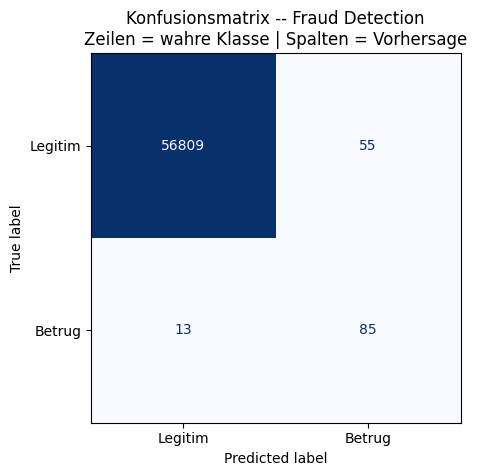

TN (Legitim korrekt):    56,809
FP (Fehlalarm):          55
FN (Betrug verpasst):    13  <- kritisch!
TP (Betrug erkannt):     85

Recall Betrug:    0.867 (86.7% aller Betruegsfaelle erkannt)
Precision Betrug: 0.607 (60.7% der Alarme sind echt)


In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Legitim', 'Betrug']
)
disp.plot(cmap='Blues', colorbar=False, values_format='d')
plt.title('Konfusionsmatrix -- Fraud Detection\n'
          'Zeilen = wahre Klasse | Spalten = Vorhersage')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN (Legitim korrekt):    {tn:,}')
print(f'FP (Fehlalarm):          {fp}')
print(f'FN (Betrug verpasst):    {fn}  <- kritisch!')
print(f'TP (Betrug erkannt):     {tp}')
print()
print(f'Recall Betrug:    {tp/(tp+fn):.3f} ({tp/(tp+fn):.1%} aller Betruegsfaelle erkannt)')
print(f'Precision Betrug: {tp/(tp+fp):.3f} ({tp/(tp+fp):.1%} der Alarme sind echt)')


## 8. Classification Report

Der `classification_report` fasst alle Metriken uebersichtlich zusammen.
Fuer Fraud Detection schauen wir vor allem auf **Klasse 1 (Betrug)**.


In [9]:
print(classification_report(
    y_test, y_pred,
    target_names=['Legitim', 'Betrug']
))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')


              precision    recall  f1-score   support

     Legitim       1.00      1.00      1.00     56864
      Betrug       0.61      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9795


## 9. ROC-Kurve und Precision-Recall-Kurve

**ROC-Kurve**: zeigt Trennfaehigkeit ueber alle Schwellwerte.
Bei extremem Ungleichgewicht (0.17% Betrug) kann die ROC-AUC trueberisch
optimistisch wirken.

**Precision-Recall-Kurve** (PR-Kurve): relevanter bei extremem Ungleichgewicht.
Sie zeigt den Trade-off: mehr Recall -> weniger Precision.

> **Merksatz:** Bei sehr seltenen Ereignissen (< 1%) ist die PR-Kurve
> oft aussagekraeftiger als die ROC-Kurve.


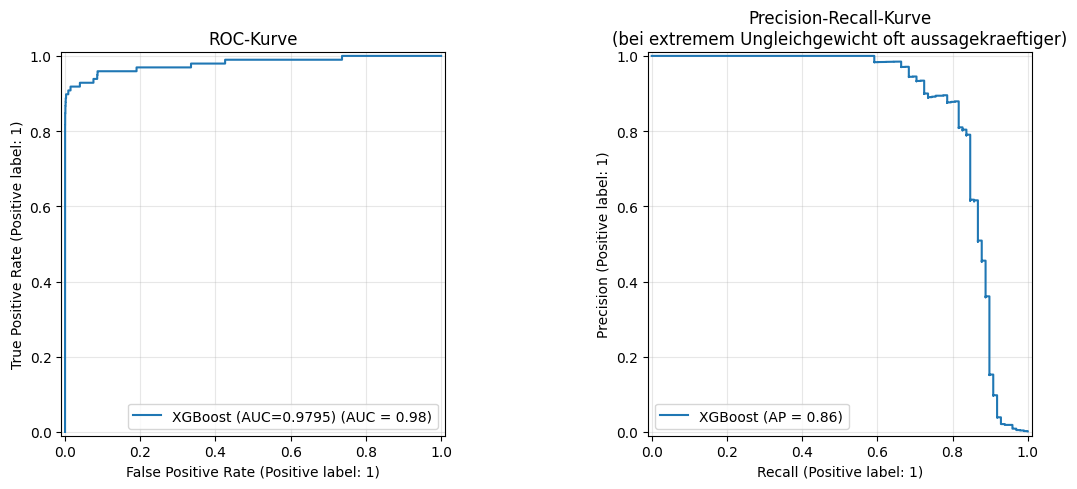

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC-Kurve
RocCurveDisplay.from_predictions(
    y_test, y_proba, ax=axes[0],
    name=f'XGBoost (AUC={roc_auc_score(y_test, y_proba):.4f})'
)
axes[0].set_title('ROC-Kurve')
axes[0].grid(True, alpha=0.3)

# Precision-Recall-Kurve
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba, ax=axes[1],
    name='XGBoost'
)
axes[1].set_title('Precision-Recall-Kurve\n'
                  '(bei extremem Ungleichgewicht oft aussagekraeftiger)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Schwellwert-Anpassung: Precision vs. Recall steuern

Der Standard-Schwellwert 0.5 ist bei Fraud Detection oft nicht optimal.

**Geschaeftliche Entscheidung:**
- Niedrigerer Schwellwert -> mehr Betrug erkannt, aber mehr Fehlalarme
- Hoeherer Schwellwert -> weniger Fehlalarme, aber mehr Betrug verpasst

Welcher Schwellwert sinnvoll ist, haengt von den **Kosten** ab:
Was ist teurer -- ein verpasster Betrug oder ein Fehlalarm?


In [11]:
print(f'Vergleich verschiedener Schwellwerte:')
print(f'{"Schwellwert":>12} | {"Precision":>10} | {"Recall":>8} '
      f'| {"F1":>8} | {"Alarm-Faelle":>13}')
print('-' * 62)

for sw in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_sw = (y_proba >= sw).astype(int)
    if y_sw.sum() > 0 and (1 - y_sw).sum() > 0:
        p = precision_score(y_test, y_sw, zero_division=0)
        r = recall_score(y_test, y_sw)
        f = f1_score(y_test, y_sw)
        n_alarm = y_sw.sum()
        marker = '  <- Standard' if sw == 0.5 else ''
        print(f'{sw:>12.1f} | {p:>10.3f} | {r:>8.3f} '
              f'| {f:>8.3f} | {n_alarm:>13,}{marker}')

print()
print('Beobachtung: Schwellwert 0.3 erkennt mehr Betrug (Recall steigt),')
print('aber loest mehr Fehlalarme aus (Precision sinkt).')


Vergleich verschiedener Schwellwerte:
 Schwellwert |  Precision |   Recall |       F1 |  Alarm-Faelle
--------------------------------------------------------------
         0.1 |      0.206 |    0.898 |    0.335 |           427
         0.2 |      0.360 |    0.888 |    0.512 |           242
         0.3 |      0.470 |    0.878 |    0.612 |           183
         0.4 |      0.541 |    0.867 |    0.667 |           157
         0.5 |      0.607 |    0.867 |    0.714 |           140  <- Standard

Beobachtung: Schwellwert 0.3 erkennt mehr Betrug (Recall steigt),
aber loest mehr Fehlalarme aus (Precision sinkt).


## 11. Feature Importance

Die Features V1-V28 sind anonymisiert (PCA-Komponenten) -- wir koennen
sie inhaltlich nicht direkt deuten. Aber wir sehen, welche Komponenten
das Modell als besonders trennend erachtet.

`Time` und `Amount` sind im Original-Massstab erhalten:
- Hat der Zeitpunkt einer Transaktion Einfluss auf das Betrugsrisiko?
- Sind bestimmte Betraege verdaechtiger?


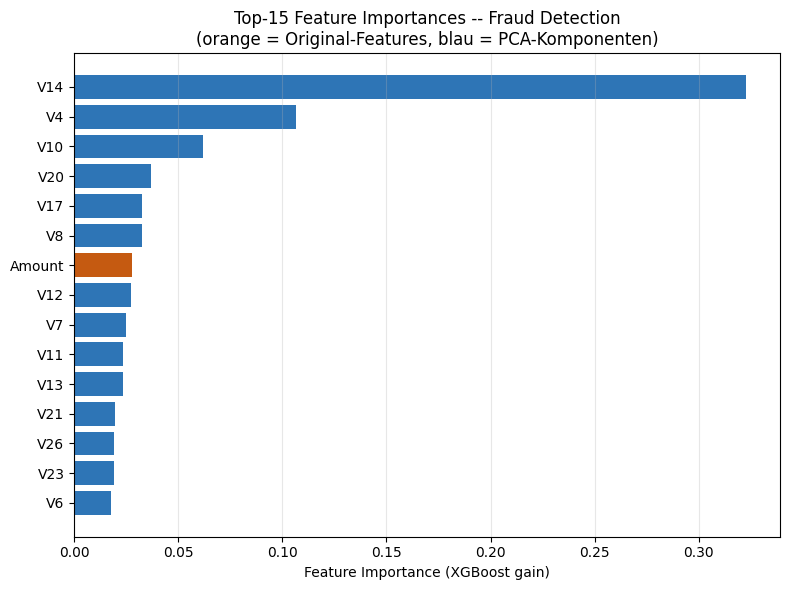

Top-5 Features:
Feature  Importance
    V14    0.322875
     V4    0.106713
    V10    0.061790
    V20    0.037016
    V17    0.032462


In [12]:
importances = model.feature_importances_
feature_names = X.columns.tolist()

fi_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=False)
           .reset_index(drop=True))

# Top-15 als horizontaler Barplot
top = fi_df.head(15)
plt.figure(figsize=(8, 6))
plt.barh(
    top['Feature'][::-1], top['Importance'][::-1],
    color=['#C55A11' if f in ['Time','Amount'] else '#2E75B6'
           for f in top['Feature'][::-1]]
)
plt.xlabel('Feature Importance (XGBoost gain)')
plt.title('Top-15 Feature Importances -- Fraud Detection\n'
          '(orange = Original-Features, blau = PCA-Komponenten)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Top-5 Features:')
print(fi_df.head(5).to_string(index=False))


## 12. Mini-Uebungen

### Aufgabe 1: Baumtiefe variieren
Aendere `max_depth` auf 2 und auf 10. Was passiert mit Recall und Precision?

### Aufgabe 2: Schwellwert optimieren
Welcher Schwellwert maximiert den F1-Score fuer die Betrugs-Klasse?
Ergaenze die Tabelle aus Abschnitt 10 um Schwellwert 0.05 und 0.08.

### Aufgabe 3: Ohne scale_pos_weight
Trainiere ein zweites Modell ohne `scale_pos_weight`.
Wie aendert sich der Recall fuer Betruegsfaelle?

### Aufgabe 4: Vergleich mit Random Forest
Trainiere einen `RandomForestClassifier` mit `class_weight='balanced'`.
Welches Modell hat den hoeheren ROC-AUC?


### Musterlösungen / Dozentenhinweise

**Aufgabe 1 (max_depth):**
- `max_depth=2`: Recall sinkt stark (Baum zu einfach, erkennt wenige Betruegsfaelle)
- `max_depth=10`: Recall bleibt hoch, aber Precision koennte sinken (Overfitting)
- Optimum liegt meist bei 3-6 fuer diesen Datensatz

**Aufgabe 2 (Schwellwert):**
Der F1-optimale Schwellwert liegt typischerweise bei 0.1-0.2 (unter 0.5),
weil `scale_pos_weight` das Modell bereits in Richtung Recall verschiebt.

**Aufgabe 3 (ohne scale_pos_weight):**
Recall fuer Betrug faellt dramatisch -- das Modell ignoriert die seltene Klasse.
Das demonstriert, warum die Gewichtung unverzichtbar ist.

**Aufgabe 4 (Random Forest):**
Auf diesem Datensatz liegen RF und XGBoost oft nahe beieinander im ROC-AUC.
XGBoost ist typischerweise 0.5-1% vorne und deutlich schneller im Training.

**Didaktischer Hinweis:**
Fraud Detection ist ein idealer Kontext um zu zeigen, dass ML-Modelle
immer im Kontext der Kosten fehlerhafter Vorhersagen bewertet werden muessen.
Der Schwellwert ist eine Geschaeftsentscheidung, keine technische.


## Bonus: SHAP-Werte -- Warum klassifiziert das Modell so?

SHAP (SHapley Additive exPlanations) erklaert fuer jeden einzelnen Datenpunkt,
welche Features die Vorhersage in welche Richtung beeinflusst haben.

```python
# Installation:
# !pip install shap
```

Das ist besonders wertvoll bei anonymisierten Features:
Wir koennen zwar nicht sagen 'Feature V14 bedeutet X', aber wir sehen,
ob ein hoher oder niedriger V14-Wert die Betrugs-Wahrscheinlichkeit erhoet.


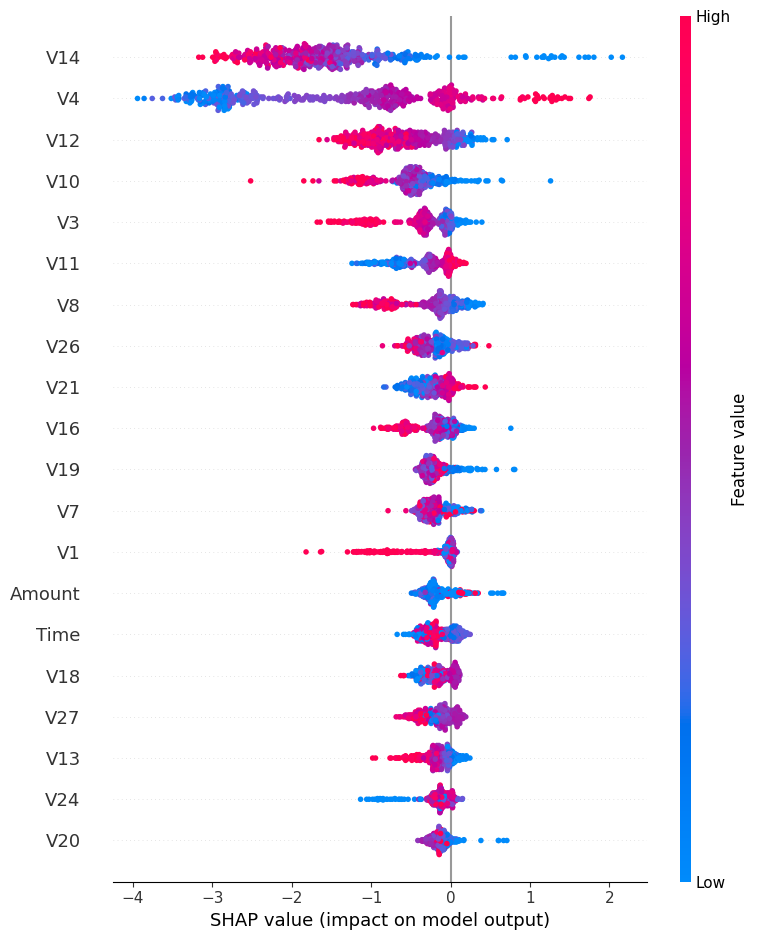

Lesehilfe:
- Rote Punkte: hoher Feature-Wert
- Blaue Punkte: niedriger Feature-Wert
- Rechts von 0: Feature erhoet Betrugs-Wahrscheinlichkeit
- Links von 0:  Feature senkt Betrugs-Wahrscheinlichkeit


In [13]:
try:
    import shap

    # SHAP-Werte berechnen (auf einem Subset fuer Geschwindigkeit)
    X_shap = X_test.iloc[:500]   # 500 Testpunkte reichen fuer Visualisierung

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    # Summary Plot: globale Feature-Bedeutung + Richtung
    shap.summary_plot(
        shap_values, X_shap,
        plot_type='dot',
        show=True
    )
    print('Lesehilfe:')
    print('- Rote Punkte: hoher Feature-Wert')
    print('- Blaue Punkte: niedriger Feature-Wert')
    print('- Rechts von 0: Feature erhoet Betrugs-Wahrscheinlichkeit')
    print('- Links von 0:  Feature senkt Betrugs-Wahrscheinlichkeit')

except ImportError:
    print('SHAP nicht installiert. Bitte: !pip install shap')


## Zusammenfassung

### Was wir auf dem Credit-Card-Fraud-Datensatz gelernt haben

| Problem | Loesung |
|---|---|
| Extremes Ungleichgewicht (0.17% Betrug) | `scale_pos_weight` in XGBoost |
| Accuracy irrefuehrend | Recall, Precision, F1, ROC-AUC |
| Schwellwert 0.5 nicht optimal | Schwellwert-Anpassung nach Kosten |
| Anonymisierte Features | Feature Importance + SHAP |

### Merksaetze

- **Recall** ist bei Fraud Detection wichtiger als Precision:
  jeder verpasste Betrug ist ein echter finanzieller Schaden
- **`scale_pos_weight`** macht XGBoost fit fuer extremes Ungleichgewicht
- Der **Schwellwert** ist eine Geschaeftsentscheidung, keine technische
- **PR-Kurve** ist bei seltenen Ereignissen (< 1%) aussagekraeftiger als ROC
- **SHAP** erlaubt Erklaerbarkeit auch bei anonymisierten Features

> Dieses Notebook zeigt, warum XGBoost in der Praxis so dominant ist:
> reale Daten sind unausgeglichen, verrauscht und schwer interpretierbar
> -- genau die Situation, fuer die XGBoost optimiert wurde.
